<a href="https://colab.research.google.com/github/PreethaSaha/SpacedOut/blob/main/Grab_TLE_Interp_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#pip install pyorbital # not being used in this code currently

In [ ]:
#transforming the pulled data to txt file for easy reading

#from pathlib import Path

#folder = Path("Insert your folder path address")

#folders = [
#    Path("Insert your folder path address"),
#    Path("Insert your folder path address"),
#    Path("Insert your folder path address")
#] #---for multiple folders

#output_file = "processed_output.txt"

#output_file = "processed_output_3pulls.txt"

'''
with open(output_file, "w") as out:
    for folder in folders:
        for file in folder.glob("*.txt"):
            with file.open("r") as f:
                for line in f:
                    processed = line.strip().upper()  #transformation
                    out.write(processed + "\n")
'''

'\nwith open(output_file, "w") as out:\n    for folder in folders:\n        for file in folder.glob("*.txt"):\n            with file.open("r") as f:\n                for line in f:\n                    processed = line.strip().upper()  #transformation\n                    out.write(processed + "\n")\n'

## Installing the required dependencies

In [ ]:
import pandas as pd
import requests
import json
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os

#from pyorbital import tlefile

## Parsing the TLE (from the input file) for the required data columns

In [ ]:

from datetime import datetime, timedelta

def parse_epoch(epoch_str):
    """Convert TLE epoch YYDDD.DDDDDDDD to datetime (UTC)."""
    year = int(epoch_str[0:2])
    year += 2000 if year < 57 else 1900  # TLE epoch rule
    doy = float(epoch_str[2:])  # day of year + fractional day
    day = int(doy)
    frac_day = doy - day
    dt = datetime(year, 1, 1) + timedelta(days=day - 1, seconds=frac_day * 86400)
    return dt

def parse_tle(file_path):
    results = []
    with open(file_path, "r") as f:
        lines = f.readlines()
        for i in range(0, len(lines), 2):  # step through pairs of lines
            line1, line2 = lines[i].strip(), lines[i+1].strip()
            catalog = line1[2:7]
            epoch_str = line1[18:32].strip()
            mean_motion = line2[52:63].strip()
            #parse eccentricity (columns 27–33 on line 2, with implied decimal)
            eccentricity_str = line2[26:33].strip()
            eccentricity = float(f"0.{eccentricity_str}")

            # parse inclination (columns 9–16 on line 2)
            inclination = float(line2[8:16].strip())

            # parse B* drag term (line 1, cols 54–61)
            bstar_str = line1[53:61].strip()
            # format like "10270-3" → "0.10270e-3"
            if "-" in bstar_str or "+" in bstar_str:
                base, exp = bstar_str[:-2], bstar_str[-2:]
                bstar = float(f"{base}e{exp}")
            else:
                bstar = float(bstar_str)

            epoch_dt = parse_epoch(epoch_str)
            results.append((catalog, epoch_dt, float(mean_motion), eccentricity, inclination, bstar))
    return results


# Using the processed file -
tle_file = "processed_output_3pulls.txt" # Insert the INPUT FILE HERE.
data = parse_tle(tle_file)

for catalog, epoch_dt, mm, e, i, b in data[:10]:  # print first 10
    print(f"Catalog: {catalog}, Epoch: {epoch_dt}, Mean Motion: {mm}, Eccentricity: {e}, Inclination: {i}, drag: {b}")

Catalog: 55022, Epoch: 2025-01-01 16:30:24.015744, Mean Motion: 15.42947494, Eccentricity: 0.0007332, Inclination: 97.3925, drag: 125.61
Catalog: 55022, Epoch: 2025-01-01 16:30:24.015744, Mean Motion: 15.42947494, Eccentricity: 0.0007332, Inclination: 97.3925, drag: 125.61
Catalog: 55022, Epoch: 2025-01-02 22:04:42.106656, Mean Motion: 15.43079275, Eccentricity: 0.0007363, Inclination: 97.3919, drag: 96.355
Catalog: 55022, Epoch: 2025-01-03 10:31:44.094720, Mean Motion: 15.43125179, Eccentricity: 0.0007404, Inclination: 97.392, drag: 85.149
Catalog: 55022, Epoch: 2025-01-04 03:38:52.476000, Mean Motion: 15.43176499, Eccentricity: 0.0007419, Inclination: 97.3919, drag: 72.769
Catalog: 55022, Epoch: 2025-01-04 03:38:52.476000, Mean Motion: 15.43176499, Eccentricity: 0.0007419, Inclination: 97.3919, drag: 72.769
Catalog: 55022, Epoch: 2025-01-04 22:19:20.796384, Mean Motion: 15.43248219, Eccentricity: 0.0007445, Inclination: 97.3916, drag: 96.628
Catalog: 55022, Epoch: 2025-01-05 02:59:27

## parsed 'data' to dataframe: df

In [ ]:

df = pd.DataFrame(data, columns=["catalog", "epoch", "mean_motion", "eccentricity", "orb incli", "drag"])
#print(df[:10])
df["epoch"] = pd.to_datetime(df["epoch"])  # ensure datetime for the second time

In [ ]:
df

,catalog,epoch,mean_motion,eccentricity,orb incli,drag
0,55022,2025-01-01 16:30:24.015744,15.429475,0.000733,97.3925,125.6100
1,55022,2025-01-01 16:30:24.015744,15.429475,0.000733,97.3925,125.6100
2,55022,2025-01-02 22:04:42.106656,15.430793,0.000736,97.3919,96.3550
3,55022,2025-01-03 10:31:44.094720,15.431252,0.000740,97.3920,85.1490
4,55022,2025-01-04 03:38:52.476000,15.431765,0.000742,97.3919,72.7690
...,...,...,...,...,...,...
222420,43802,2020-12-29 04:03:03.333312,15.334996,0.000578,97.2269,5.9391
222421,43802,2020-12-29 05:37:01.138080,15.335005,0.000577,97.2269,6.2363
222422,43802,2020-12-29 18:08:43.731744,15.335022,0.000574,97.2269,6.0205
222423,43802,2020-12-30 11:22:19.685280,15.335050,0.000571,97.2267,5.9298


## removing the duplicates if all four entries are exactly same and resetting the index: df_new

In [ ]:
df_new = df.drop_duplicates(subset=["catalog", "epoch", "mean_motion", "eccentricity"]).reset_index(drop=True)
df_new[:10]

,catalog,epoch,mean_motion,eccentricity,orb incli,drag
0,55022,2025-01-01 16:30:24.015744,15.429475,0.000733,97.3925,125.610
1,55022,2025-01-02 22:04:42.106656,15.430793,0.000736,97.3919,96.355
2,55022,2025-01-03 10:31:44.094720,15.431252,0.000740,97.3920,85.149
3,55022,2025-01-04 03:38:52.476000,15.431765,0.000742,97.3919,72.769
4,55022,2025-01-04 22:19:20.796384,15.432482,0.000745,97.3916,96.628
5,55022,2025-01-05 02:59:27.322656,15.432687,0.000741,97.3919,97.035
6,55022,2025-01-05 10:46:17.857920,15.432950,0.000744,97.3917,87.110
7,55022,2025-01-06 03:53:19.361760,15.433527,0.000743,97.3916,84.319
8,55022,2025-01-06 17:53:35.331648,15.433970,0.000747,97.3918,79.041
9,55022,2025-01-07 03:13:45.229728,15.434239,0.000743,97.3921,76.649


In [ ]:
df_new

,catalog,epoch,mean_motion,eccentricity,orb incli,drag
0,55022,2025-01-01 16:30:24.015744,15.429475,0.000733,97.3925,125.6100
1,55022,2025-01-02 22:04:42.106656,15.430793,0.000736,97.3919,96.3550
2,55022,2025-01-03 10:31:44.094720,15.431252,0.000740,97.3920,85.1490
3,55022,2025-01-04 03:38:52.476000,15.431765,0.000742,97.3919,72.7690
4,55022,2025-01-04 22:19:20.796384,15.432482,0.000745,97.3916,96.6280
...,...,...,...,...,...,...
185511,43802,2020-12-28 18:39:16.334496,15.334982,0.000580,97.2270,5.9459
185512,43802,2020-12-29 04:03:03.333312,15.334996,0.000578,97.2269,5.9391
185513,43802,2020-12-29 05:37:01.138080,15.335005,0.000577,97.2269,6.2363
185514,43802,2020-12-29 18:08:43.731744,15.335022,0.000574,97.2269,6.0205


## calculate the total no. of unique satellites ID & total no. of entries each has

In [ ]:
# calculation after removing the duplicates
Counts = df_new['catalog'].value_counts()

print("Number of unique NORAD IDs after removing duplicates:", df_new['catalog'].nunique())
print("Unique IDs:", df_new['catalog'].unique())
print(Counts)

Number of unique NORAD IDs after removing duplicates: 136
Unique IDs: ['55022' '55023' '58311' '58307' '58306' '55043' '55042' '60519' '60518'
 '55077' '55028' '55029' '58273' '58329' '55032' '43788' '55024' '60509'
 '58274' '58322' '60515' '39429' '55074' '58327' '58270' '58271' '55063'
 '58283' '58319' '58318' '55068' '55020' '62659' '58313' '60481' '62645'
 '40031' '55065' '39132' '58320' '43821' '58309' '58308' '60517' '55027'
 '58303' '60501' '60489' '60488' '60513' '60512' '60483' '60482' '58280'
 '60505' '62613' '60494' '60495' '58328' '60499' '60503' '62663' '60502'
 '58316' '60492' '58275' '58286' '60514' '60563' '60484' '62636' '60497'
 '58282' '62666' '58304' '60480' '60559' '62639' '60558' '62670' '60511'
 '58284' '58285' '60487' '60486' '62643' '60516' '60561' '58315' '60560'
 '62622' '60490' '60491' '62661' '62685' '42988' '42989' '41772' '41773'
 '62678' '62679' '62631' '62646' '62647' '58296' '62680' '62681' '62651'
 '62650' '42992' '41601' '39418' '62621' '41774' '6267

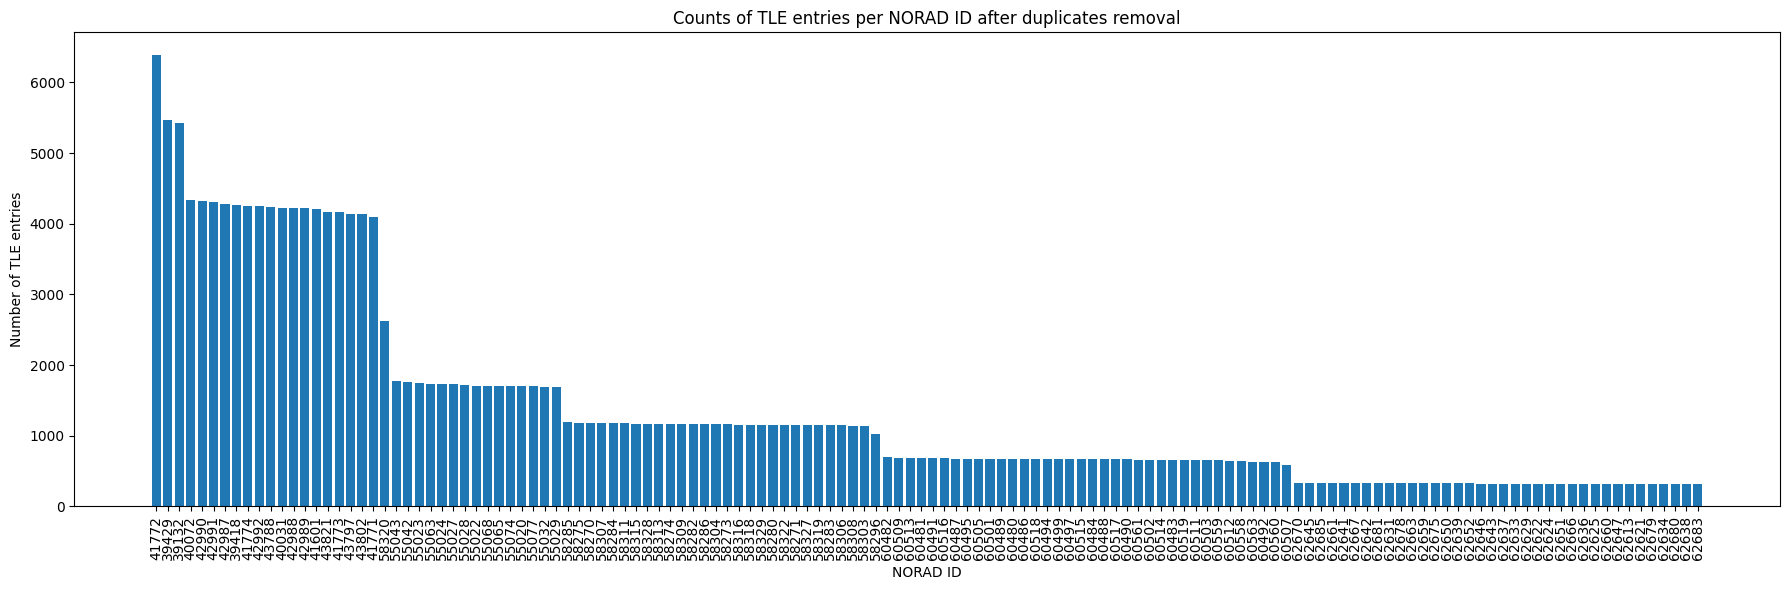

In [ ]:
plt.figure(figsize=(18,6))
plt.bar(Counts.index.astype(str), Counts.values)
plt.xlabel("NORAD ID")
plt.ylabel("Number of TLE entries")
plt.title("Counts of TLE entries per NORAD ID after duplicates removal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Written by Jessica - not used here currently

In [ ]:
## If trying to run this in collab, you'll need the file in your Google Drive
#with open("WeatherSat_GP.csv",'r') as f:
#    lines = f.readlines()
'''
planet_norad_url = "https://ephemerides.planet-labs.com/18SPCS_matches.txt"
resp = requests.get(url)
if resp.status_code == 200:
    lines = resp.text.split("\n")
    # optionally save off to file
    with open("planet_ids.txt",'r') as f:
        f.writelines(lines)

planet_info = []
for line in lines[9:]:
    components = line.split(" ")
    hwid = components[0]
    name = " ".join(components[2:6]).strip()
    noradid = line.split(name)[1].strip().split(" ")[0]
    if noradid != "": noradid=int(noradid)
    planet_info.append({'hwid':hwid,'name':name,'noradid':noradid})

norad_ids = [d["noradid"] for d in planet_info]
'''

'\nplanet_norad_url = "https://ephemerides.planet-labs.com/18SPCS_matches.txt"\nresp = requests.get(url)\nif resp.status_code == 200:\n    lines = resp.text.split("\n")\n    # optionally save off to file\n    with open("planet_ids.txt",\'r\') as f:\n        f.writelines(lines)\n\nplanet_info = []\nfor line in lines[9:]:\n    components = line.split(" ")\n    hwid = components[0]\n    name = " ".join(components[2:6]).strip()\n    noradid = line.split(name)[1].strip().split(" ")[0]\n    if noradid != "": noradid=int(noradid)\n    planet_info.append({\'hwid\':hwid,\'name\':name,\'noradid\':noradid})\n\nnorad_ids = [d["noradid"] for d in planet_info]\n'

## Setup Space-track - not used currently here as the data is parsed from the input file

In [ ]:
# Log-in and Start a Session
session = requests.Session()
spacetrack = session.post(login_url, data=spacetrack_config)

In [ ]:
# API credentials
## Ideally parse in from a file, but otherwise:
spacetrack_config = {}
spacetrack_config['identity'] = "YOUR USERNAME GOES HERE"
spacetrack_config['password'] = "YOUR PASSWORD GOES HERE

In [ ]:
# How many days of TLEs to gather
NUM_DAYS = 365

## Written by Jessica - Download and Interpret TLEs, not used here currently

In [ ]:
'''tle_interp = []
for sat in norad_ids:
    tles = []
    if str(norad_id) != "":
        tle_url = tle_endpoint.replace("<noradid>", str(sat))
        req = session.get(sat['tle_url'])
        if req.status_code == 200:
            tles = tlefile._parse_tles_for_downloader((req.text,), io.StringIO)
    for tle in tles:
        tle_interp.append({'satnumber':tle.satnumber,
                           'classification':tle.classification,
                           'id_launch_year': tle.id_launch_year,
                           'id_launch_number':tle.id_launch_number,
                           'epoch_year':tle.epoch_year,
                           'epoch_day':tle.epoch_day,
                           'epoch':tle.epoch,
                           'mean_motion_derivative':tle.mean_motion_derivative,
                           'mean_motion_sec_derivative':tle.mean_motion_sec_derivative,
                           'bstar':tle.bstar,
                           'ephemeris_type':tle.ephemeris_type,
                           'element_number':tle.element_number,
                           'inclination':tle.inclination,
                           'right_ascension':tle.right_ascension,
                           'excentricity':tle.excentricity,
                           'arg_perigee':tle.arg_perigee,
                           'mean_anomaly':tle.mean_anomaly,
                           'mean_motion':tle.mean_motion,
                           'orbit':tle.orbit})
tle_df = pd.DataFrame(tle_interp)'''

In [ ]:
#tle_df['epoch'] = pd.to_datetime(tle_df['epoch'], format='%Y-%m-%d %H:%M:%S.%f')

In [ ]:
# save off interpreted data
#tle_df.to_csv("tle_interp.csv")

## After calculating the unique satellites code block - continue from here

In [ ]:
print(df_new.head(10))

  catalog                      epoch  mean_motion  eccentricity  orb incli  \
0   55022 2025-01-01 16:30:24.015744    15.429475      0.000733    97.3925   
1   55022 2025-01-02 22:04:42.106656    15.430793      0.000736    97.3919   
2   55022 2025-01-03 10:31:44.094720    15.431252      0.000740    97.3920   
3   55022 2025-01-04 03:38:52.476000    15.431765      0.000742    97.3919   
4   55022 2025-01-04 22:19:20.796384    15.432482      0.000745    97.3916   
5   55022 2025-01-05 02:59:27.322656    15.432687      0.000741    97.3919   
6   55022 2025-01-05 10:46:17.857920    15.432950      0.000744    97.3917   
7   55022 2025-01-06 03:53:19.361760    15.433527      0.000743    97.3916   
8   55022 2025-01-06 17:53:35.331648    15.433970      0.000747    97.3918   
9   55022 2025-01-07 03:13:45.229728    15.434239      0.000743    97.3921   

      drag  
0  125.610  
1   96.355  
2   85.149  
3   72.769  
4   96.628  
5   97.035  
6   87.110  
7   84.319  
8   79.041  
9   76.649 

# visualize how does the mean motion of the satellites vary over the years

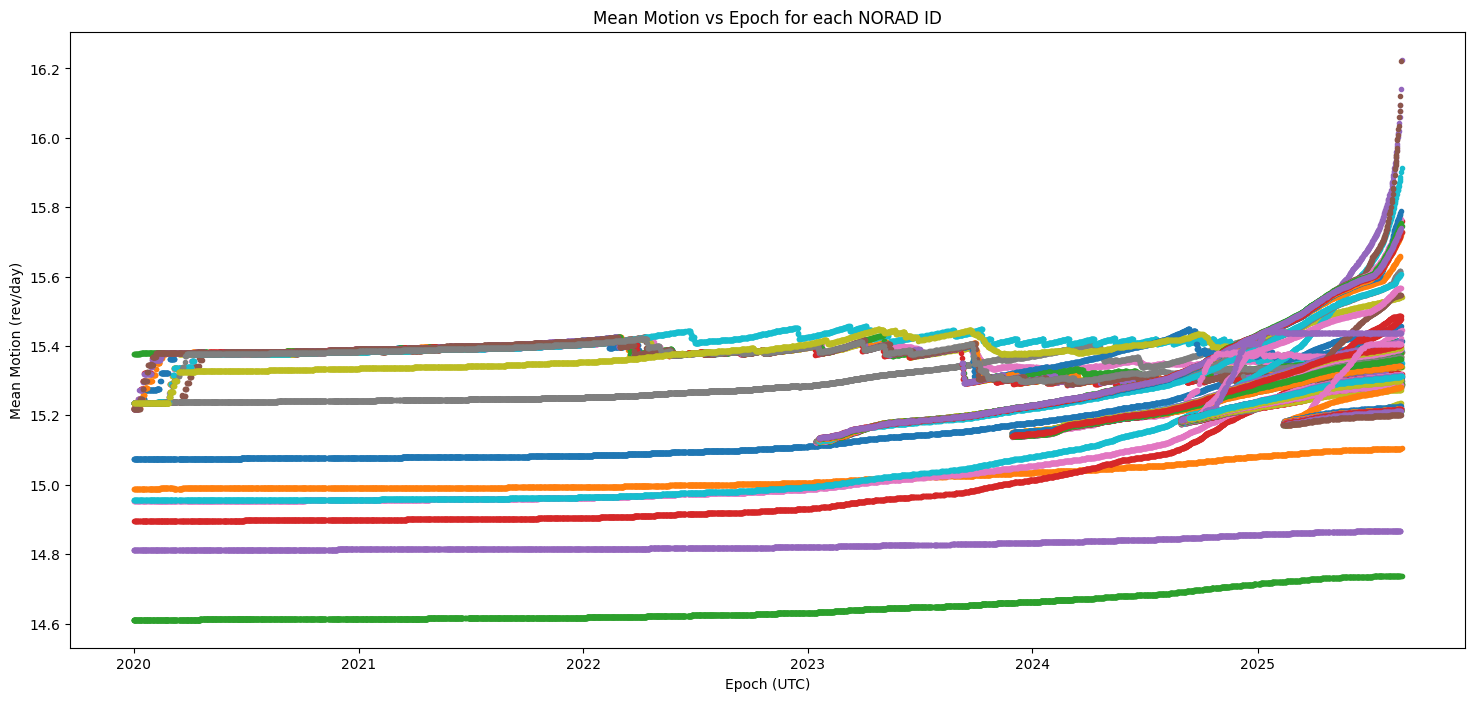

In [ ]:
plt.figure(figsize=(18,8))

for catalog, group in df_new.groupby("catalog"):
    plt.plot(group["epoch"], group["mean_motion"], marker=".", linestyle="none", label=f"{catalog}")

plt.xlabel("Epoch (UTC)")
plt.ylabel("Mean Motion (rev/day)")
plt.title("Mean Motion vs Epoch for each NORAD ID")
#plt.legend(ncols=8)
plt.show()

## daily averaging the data columns and resetting the index: df_new_daily -- also helps in reducing the data size

In [ ]:
df_new["date"] = df_new["epoch"].dt.date
temp=df_new[df_new['catalog'].astype(str) == "55022"]
temp=temp.sort_values('date')
print(temp) # prints the entries of sat ID before daily averaging
#df_new_daily = df_new.groupby(["catalog", "date"])["mean_motion"].mean().reset_index(drop=False)
df_new_daily = (
    df_new.groupby(["catalog", "date"])[["mean_motion", "eccentricity", "orb incli", "drag"]]
    .mean()
    .reset_index(drop=False)
)

print(df_new_daily[df_new_daily['catalog'].astype(str) == "55022"]) # prints the entries of same sat ID after daily averaging

      catalog                      epoch  mean_motion  eccentricity  \
12336   55022 2023-01-13 07:46:06.024576    15.124233      0.001166   
12337   55022 2023-01-13 18:53:00.133440    15.124315      0.001169   
12338   55022 2023-01-14 13:56:15.261216    15.124439      0.001173   
12339   55022 2023-01-15 13:45:18.298944    15.124612      0.001185   
12340   55022 2023-01-16 21:30:40.542912    15.124885      0.001196   
...       ...                        ...          ...           ...   
409     55022 2025-08-17 18:49:06.455136    15.651596      0.000126   
410     55022 2025-08-18 04:01:28.595712    15.652614      0.000117   
411     55022 2025-08-19 04:34:17.563584    15.655332      0.000107   
412     55022 2025-08-19 18:22:38.037792    15.656991      0.000109   
413     55022 2025-08-20 17:22:59.113920    15.660040      0.000110   

       orb incli     drag        date  
12336    97.5015   45.911  2023-01-13  
12337    97.5017   47.978  2023-01-13  
12338    97.5020   45.729  

In [ ]:
df_new_daily # 90830 entries

,catalog,date,mean_motion,eccentricity,orb incli,drag
0,39132,2020-01-01,15.074390,0.003556,64.875350,2.330450
1,39132,2020-01-02,15.074390,0.003559,64.875667,1.868633
2,39132,2020-01-03,15.074391,0.003567,64.875500,1.515450
3,39132,2020-01-04,15.074395,0.003572,64.875300,1.300780
4,39132,2020-01-05,15.074399,0.003582,64.874967,1.258233
...,...,...,...,...,...,...
90825,62685,2025-08-17,15.201008,0.000479,97.423050,22.228500
90826,62685,2025-08-18,15.201074,0.000476,97.423100,22.486000
90827,62685,2025-08-19,15.201204,0.000467,97.423250,23.641500
90828,62685,2025-08-20,15.201335,0.000461,97.423500,24.968500


## Function to convert mean motion to semi major axis(km)

In [ ]:
MU = 398600.4418  # km^3 / s^2

def mean_motion_to_semi_major_axis(mean_motion):
    """
    Convert mean motion (rev/day) to semi-major axis (km).
    """
    n_rad_s = mean_motion * 2 * np.pi / 86400.0  # rev/day to rad/s
    a = (MU / (n_rad_s**2))**(1/3)
    return a

## apply the func to df_new_daily's mean motion column and add column semi major axis

In [ ]:
df_new_daily["semi_major_axis_km"] = df_new_daily["mean_motion"].apply(mean_motion_to_semi_major_axis)

## Function to compute perigee alltitude(km) or height (min height)

In [ ]:
def compute_altitude(semi_major_axis_km, eccentricity, earth_radius=6378.137):
    """
    Compute perigee and apogee altitudes from semi-major axis and eccentricity.

    Parameters
    ----------
    semi_major_axis : float
        Semi-major axis in km
    eccentricity : float
        Orbital eccentricity (0 <= e < 1)
    earth_radius : float, optional
        Mean radius of Earth in km (default 6378.137 km)

    Returns
    -------

        (perigee_altitude_km)
    """
    r_perigee = semi_major_axis_km * (1 - eccentricity)

    h_perigee = r_perigee - earth_radius

    return h_perigee


## apply the func to df_new_daily's semi major axis, eccentricity columns and add column perigee height (h_p_km)

In [ ]:
df_new_daily["h_p_km"] = df_new_daily.apply(
    lambda row: compute_altitude(row["semi_major_axis_km"], row["eccentricity"]),
    axis=1
)

In [ ]:
df_new_daily #added semi major axis, perigee altitude columns - 90830 entries

,catalog,date,mean_motion,eccentricity,orb incli,drag,semi_major_axis_km,h_p_km
0,39132,2020-01-01,15.074390,0.003556,64.875350,2.330450,6922.166147,519.413924
1,39132,2020-01-02,15.074390,0.003559,64.875667,1.868633,6922.166097,519.394492
2,39132,2020-01-03,15.074391,0.003567,64.875500,1.515450,6922.165582,519.334795
3,39132,2020-01-04,15.074395,0.003572,64.875300,1.300780,6922.164604,519.304124
4,39132,2020-01-05,15.074399,0.003582,64.874967,1.258233,6922.163325,519.232059
...,...,...,...,...,...,...,...,...
90825,62685,2025-08-17,15.201008,0.000479,97.423050,22.228500,6883.673280,502.236247
90826,62685,2025-08-18,15.201074,0.000476,97.423100,22.486000,6883.653500,502.237816
90827,62685,2025-08-19,15.201204,0.000467,97.423250,23.641500,6883.614242,502.259841
90828,62685,2025-08-20,15.201335,0.000461,97.423500,24.968500,6883.574432,502.264105


## Function categorize the satellites according to perigee height

In [ ]:
def altitude_group_perigee(h_p):
    if h_p < 400:
        return "Planet_low"
    #elif h_p < 800:
    elif 400 <= h_p < 800:
        return "Planet_mid"
    else:
        return "Planet_high"

# apply to perigee altitude column
df_new_daily["altitude_group"] = df_new_daily["h_p_km"].apply(altitude_group_perigee)


## Function categorize the satellites according to orbital inclination

In [ ]:
def inclination_group(inc):
    """
    Categorize orbit type based on inclination in degrees.
    """
    if inc < 10:
        return "Equatorial"
    elif inc < 60:
        return "Mid-inclination"
    elif 97 <= inc <= 99:
        return "Sun-synchronous"
    elif inc < 120:
        return "Polar"
    else:
        return "Retrograde"
df_new_daily["incli_group"] = df_new_daily["orb incli"].apply(inclination_group)


In [ ]:
df_new_daily # with altitude and inclination groups - 90830 entries

,catalog,date,mean_motion,eccentricity,orb incli,drag,semi_major_axis_km,h_p_km,altitude_group,incli_group
0,39132,2020-01-01,15.074390,0.003556,64.875350,2.330450,6922.166147,519.413924,Planet_mid,Polar
1,39132,2020-01-02,15.074390,0.003559,64.875667,1.868633,6922.166097,519.394492,Planet_mid,Polar
2,39132,2020-01-03,15.074391,0.003567,64.875500,1.515450,6922.165582,519.334795,Planet_mid,Polar
3,39132,2020-01-04,15.074395,0.003572,64.875300,1.300780,6922.164604,519.304124,Planet_mid,Polar
4,39132,2020-01-05,15.074399,0.003582,64.874967,1.258233,6922.163325,519.232059,Planet_mid,Polar
...,...,...,...,...,...,...,...,...,...,...
90825,62685,2025-08-17,15.201008,0.000479,97.423050,22.228500,6883.673280,502.236247,Planet_mid,Sun-synchronous
90826,62685,2025-08-18,15.201074,0.000476,97.423100,22.486000,6883.653500,502.237816,Planet_mid,Sun-synchronous
90827,62685,2025-08-19,15.201204,0.000467,97.423250,23.641500,6883.614242,502.259841,Planet_mid,Sun-synchronous
90828,62685,2025-08-20,15.201335,0.000461,97.423500,24.968500,6883.574432,502.264105,Planet_mid,Sun-synchronous


## calculate no. of satellites in each altitude and inclination groups

In [ ]:
# number of satellites in each altitude group
group_counts = df_new_daily.groupby("altitude_group")["catalog"].nunique().reset_index()
#group_counts.rename(columns={"catalog": "num_satellites"}, inplace=True)
group_counts.columns = ["altitude_group", "num_satellites"]
print(group_counts)

# list of satellite IDs in each group
group_ids = df_new_daily.groupby("altitude_group")["catalog"].unique().reset_index()
group_ids.rename(columns={"catalog": "satellite_ids"}, inplace=True)
print(group_ids)


  altitude_group  num_satellites
0     Planet_low              18
1     Planet_mid             136
  altitude_group                                      satellite_ids
0     Planet_low  [43821, 55020, 55022, 55023, 55024, 55027, 550...
1     Planet_mid  [39132, 39418, 39429, 40031, 40072, 41601, 417...


In [ ]:
# satellites in each inclination group
counts = df_new_daily.groupby("incli_group")["catalog"].nunique().reset_index()
counts.columns = ["incli_group", "num_satellites"]

print(counts)

# list of IDs in each group
ids = df_new_daily.groupby("incli_group")["catalog"].unique().reset_index()
ids.columns = ["incli_group", "satellite_ids"]

print(ids)


       incli_group  num_satellites
0            Polar               6
1  Sun-synchronous             135
       incli_group                                      satellite_ids
0            Polar         [39132, 41771, 41773, 41774, 43797, 43802]
1  Sun-synchronous  [39418, 39429, 40031, 40072, 41601, 41771, 417...


## visulaize how the semi major axis vary over the years

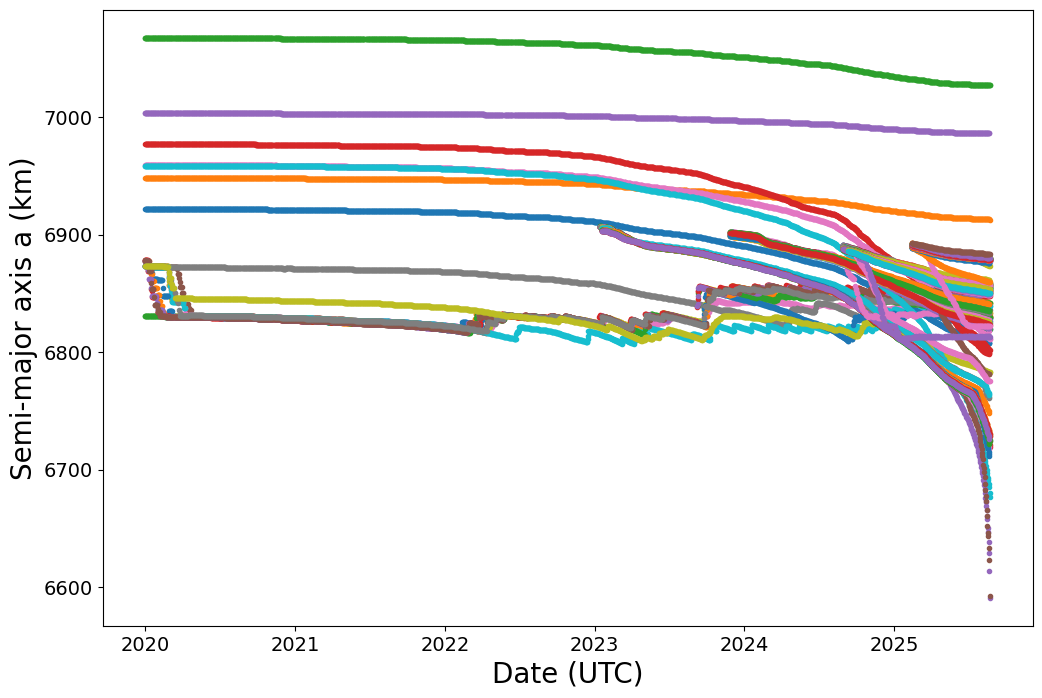

In [ ]:
plt.figure(figsize=(12,8))

#for catalog, group in df_new_daily.groupby("catalog"):
#    plt.plot(group["epoch"], group["semi_major_axis_km"], marker=".", linestyle="none", label=f"{catalog}")
for catalog, group in df_new_daily.groupby("catalog"):
  plt.plot(group["date"], group["semi_major_axis_km"], marker=".", linestyle="none", label=f"{catalog}")

plt.xlabel("Date (UTC)", fontsize=20)
plt.tick_params(axis='x', labelsize=14)
plt.ylabel("Semi-major axis a (km)", fontsize=20)
plt.tick_params(axis='y', labelsize=14)
#plt.title("Semi-major axis vs Date for each NORAD ID")
#plt.legend(ncols=8)
plt.savefig("aVSdate.png")
plt.show()

## calculate daily decay rate (delta_a/delta_t) to add to df_new_daily

In [ ]:
df_new_daily['delta_a'] = df_new_daily.groupby('catalog')['semi_major_axis_km'].diff()
#df_new_daily['delta_t'] = df_new_daily.groupby('catalog')['date'].diff().dt.total_seconds() / 3600.0  # in hours
df_new_daily['date'] = pd.to_datetime(df_new_daily['date'])
df_new_daily['delta_t'] = df_new_daily.groupby('catalog')['date'].diff().dt.days # difference in days
df_new_daily['decay_rate'] = df_new_daily['delta_a'] / df_new_daily['delta_t'] # decay rate in km/day
print(df_new_daily) # ----- FINAL df from tle to be combined with space weather df

      catalog       date  mean_motion  eccentricity  orb incli       drag  \
0       39132 2020-01-01    15.074390      0.003556  64.875350   2.330450   
1       39132 2020-01-02    15.074390      0.003559  64.875667   1.868633   
2       39132 2020-01-03    15.074391      0.003567  64.875500   1.515450   
3       39132 2020-01-04    15.074395      0.003572  64.875300   1.300780   
4       39132 2020-01-05    15.074399      0.003582  64.874967   1.258233   
...       ...        ...          ...           ...        ...        ...   
90825   62685 2025-08-17    15.201008      0.000479  97.423050  22.228500   
90826   62685 2025-08-18    15.201074      0.000476  97.423100  22.486000   
90827   62685 2025-08-19    15.201204      0.000467  97.423250  23.641500   
90828   62685 2025-08-20    15.201335      0.000461  97.423500  24.968500   
90829   62685 2025-08-22    15.201479      0.000452  97.423600  21.456000   

       semi_major_axis_km      h_p_km altitude_group      incli_group  \
0 

In [ ]:
# this is just for visualization
df_single = df_new_daily[df_new_daily["catalog"].astype(str) == "43821"]
print(df_single[["date", "decay_rate"]])


            date  decay_rate
38323 2019-12-31         NaN
38324 2020-01-01   -0.001297
38325 2020-01-02   -0.001470
38326 2020-01-03   -0.002652
38327 2020-01-04   -0.002995
...          ...         ...
40335 2025-08-18   -1.514129
40336 2025-08-19   -3.247641
40337 2025-08-20   -2.927664
40338 2025-08-22   -2.453341
40339 2025-08-23   -3.066621

[2017 rows x 2 columns]


In [ ]:
# same just for visualization
print(df_new_daily["catalog"].dtype)
print(df_new_daily[df_new_daily["catalog"].astype(str) == "43821"])


object
      catalog       date  mean_motion  eccentricity  orb incli       drag  \
38323   43821 2019-12-31    14.955073      0.001483    97.7257    2.36110   
38324   43821 2020-01-01    14.955078      0.001477    97.7257    3.09910   
38325   43821 2020-01-02    14.955082      0.001473    97.7257    3.70955   
38326   43821 2020-01-03    14.955091      0.001467    97.7257    4.58255   
38327   43821 2020-01-04    14.955100      0.001461    97.7257    5.22730   
...       ...        ...          ...           ...        ...        ...   
40335   43821 2025-08-18    15.862237      0.001110    97.4730  153.94000   
40336   43821 2025-08-19    15.873793      0.001144    97.4725  177.90000   
40337   43821 2025-08-20    15.884222      0.001159    97.4725  188.54500   
40338   43821 2025-08-22    15.901727      0.001203    97.4728  174.32000   
40339   43821 2025-08-23    15.912683      0.001221    97.4729  187.20000   

       semi_major_axis_km      h_p_km altitude_group      incli_grou

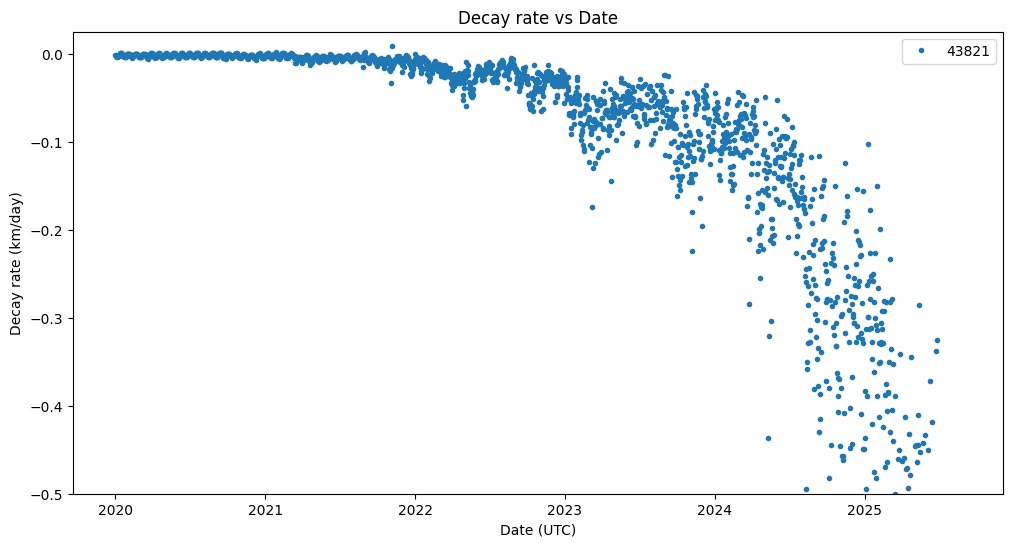

In [ ]:

# for visualization : df_single is created for this purpose only
df_single = df_new_daily[df_new_daily["catalog"].astype(str) == "43821"]

plt.figure(figsize=(12,6))
plt.plot(df_single["date"], df_single["decay_rate"], marker=".", linestyle="none", label=f"{"43821"}")
plt.ylim(-0.5,0.025)

plt.xlabel("Date (UTC)")
plt.ylabel("Decay rate (km/day)")
plt.title(f"Decay rate vs Date")
plt.legend()
plt.savefig("single_decayrate_date.png")
plt.show()



## Download Combined Geo-Magnetic and Solar Data

How to interpret: https://kp.gfz.de/app/format/Kp_ap_Ap_SN_F107_format.txt

### Other useful resources:
Background: https://www.swpc.noaa.gov/impacts/satellite-drag

NOAA Kp Plot: https://www.swpc.noaa.gov/products/planetary-k-index

KP Data source: https://kp.gfz.de/en/data

F10.7: https://www.swpc.noaa.gov/phenomena/f107-cm-radio-emissions#:~:text=2%20Hz%2D1.-,The%20F10.,activity%20over%20six%20solar%20cycles.

SN: Sunspot #

Other resource: https://solen.info/solar/old_reports/2021/january/20210102.html

## Written by Jessica to get the Space Weather data

In [ ]:
start_date = "2020-01-01"
end_date = "2025-08-24"

In [ ]:
# grab the data for the above date ranges
geo_solar_url = f"https://kp.gfz.de/kpdata?startdate={start_date}&enddate={end_date}&format=kp1#kpdatadownload-143"
resp = requests.get(geo_solar_url)
if resp.status_code == 200:
    geo_solar_data = resp.text

In [ ]:
# optionally save-off file
with open("geo_solar_raw.txt",'w') as f:
    f.writelines(geo_solar_data)

In [ ]:
# map the result into a dictionary
Kp_status_dict = {0: "preliminary", 1: "definitive", 2: "definitive"}
SN_status_dict = {0: "preliminary", 1: "preliminary", 2: "definitive"}
geo_solar_parsed = []
geo_solar_data_lines = geo_solar_data.split("\n")
for l in geo_solar_data_lines:
    info_dict = {}
    info_dict['date'] = f"{l[0:4]}-{l[5:7]}-{l[8:10]}"
    try:
        info_dict['days_since_1932'] = int(l[11:16])
    except ValueError:
        print(l)
        break
    info_dict['days_since_1932_mid'] = float(l[17:24])
    info_dict['bsr'] = int(l[25:29])
    info_dict['bd'] = int(l[30:32])
    info_dict['SN'] = int(l[135:138])
    info_dict['f107'] = float(l[139:147])
    info_dict['f107_adj'] = float(l[148:156])
    info_dict['kp_status'] = Kp_status_dict[int(l[157])]
    info_dict['sn_status'] = SN_status_dict[int(l[157])]
    kp_start = 33
    ap_start = 89
    tstart = 0
    for i in range(0,8):
        info_dict['kp'] = float(l[kp_start:kp_start+6])
        try:
            info_dict['ap'] = float(l[ap_start:ap_start+4])
        except ValueError:
            info_dict['ap'] = None
        info_dict['time'] = f"{tstart}".zfill(2)+":00:00Z"
        kp_start += 7
        ap_start += 5
        tstart += 3
        #print(info_dict.copy())
        geo_solar_parsed.append(info_dict.copy())

In [ ]:
# turn into a dataframe with proper timing
geo_solar_df = pd.DataFrame(geo_solar_parsed)
geo_solar_df['datetime'] = geo_solar_df['date'].str.cat(geo_solar_df['time'], sep='T')
geo_solar_df['datetime'] = pd.to_datetime(geo_solar_df['datetime'],format='ISO8601')

In [ ]:
geo_solar_df

,date,days_since_1932,days_since_1932_mid,bsr,bd,SN,f107,f107_adj,kp_status,sn_status,kp,ap,time,datetime
0,2020-01-01,32142,32142.5,2542,22,6,71.8,69.4,definitive,definitive,0.333,2.0,00:00:00Z,2020-01-01 00:00:00+00:00
1,2020-01-01,32142,32142.5,2542,22,6,71.8,69.4,definitive,definitive,0.000,0.0,03:00:00Z,2020-01-01 03:00:00+00:00
2,2020-01-01,32142,32142.5,2542,22,6,71.8,69.4,definitive,definitive,0.000,0.0,06:00:00Z,2020-01-01 06:00:00+00:00
3,2020-01-01,32142,32142.5,2542,22,6,71.8,69.4,definitive,definitive,0.667,3.0,09:00:00Z,2020-01-01 09:00:00+00:00
4,2020-01-01,32142,32142.5,2542,22,6,71.8,69.4,definitive,definitive,0.667,3.0,12:00:00Z,2020-01-01 12:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16499,2025-08-24,34204,34204.5,2619,5,100,151.5,154.8,definitive,preliminary,1.000,4.0,09:00:00Z,2025-08-24 09:00:00+00:00
16500,2025-08-24,34204,34204.5,2619,5,100,151.5,154.8,definitive,preliminary,1.000,4.0,12:00:00Z,2025-08-24 12:00:00+00:00
16501,2025-08-24,34204,34204.5,2619,5,100,151.5,154.8,definitive,preliminary,1.333,5.0,15:00:00Z,2025-08-24 15:00:00+00:00
16502,2025-08-24,34204,34204.5,2619,5,100,151.5,154.8,definitive,preliminary,1.667,6.0,18:00:00Z,2025-08-24 18:00:00+00:00


## Written by Preetha

# plot the variation of space weather over the time period

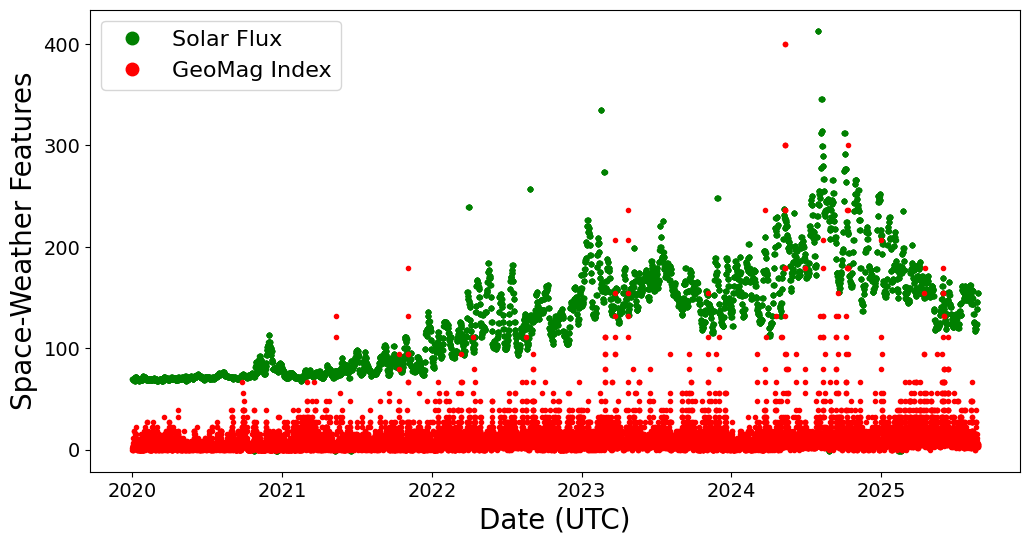

In [ ]:
#need to use f107_adj instead of f107 as it has constant earth-sun dist and Ap(daily average) instaed of ap
# for visualization, the trend of Solar flux and GeoMag activity
plt.figure(figsize=(12,6))
plt.plot(geo_solar_df["datetime"], geo_solar_df["f107_adj"], marker=".", linestyle="none", color='green',label="Solar Flux")
plt.plot(geo_solar_df["datetime"], geo_solar_df["ap"], marker=".", linestyle="none", color='red',label="GeoMag Index")
plt.xlabel("Date (UTC)", fontsize=20)
plt.xticks(fontsize=14)
plt.ylabel("Space-Weather Features", fontsize=20)
plt.yticks(fontsize=14)
#plt.title(f"f107_adj vs datetime ")
plt.legend(prop={'size': 16}, markerscale=3)
plt.savefig('flux-ap-date.png',bbox_inches='tight')
plt.show()

#plt.figure(figsize=(12,6))
#plt.plot(geo_solar_df["datetime"][1940:1970], geo_solar_df["ap"][1940:1970], marker=".", linestyle="none", color='red',label="ap")
#plt.plot(geo_solar_df["datetime"], geo_solar_df["kp"], marker=".", linestyle="none", color='blue',label="kp")
#plt.ylim(0,100)
#plt.xlim(2020,2021)
#plt.xlabel("datetime (UTC)")
#plt.ylabel("space-weather variables(kp,ap)")
#plt.legend(fontsize=10)
#plt.show()


## create a subset df 'geo_solar_subset' from df 'geo_solar_df' with only f107_adj and ap

In [ ]:
geo_solar_subset=geo_solar_df[["date", "datetime", "f107_adj", "ap"]].copy()
geo_solar_subset

,date,datetime,f107_adj,ap
0,2020-01-01,2020-01-01 00:00:00+00:00,69.4,2.0
1,2020-01-01,2020-01-01 03:00:00+00:00,69.4,0.0
2,2020-01-01,2020-01-01 06:00:00+00:00,69.4,0.0
3,2020-01-01,2020-01-01 09:00:00+00:00,69.4,3.0
4,2020-01-01,2020-01-01 12:00:00+00:00,69.4,3.0
...,...,...,...,...
16499,2025-08-24,2025-08-24 09:00:00+00:00,154.8,4.0
16500,2025-08-24,2025-08-24 12:00:00+00:00,154.8,4.0
16501,2025-08-24,2025-08-24 15:00:00+00:00,154.8,5.0
16502,2025-08-24,2025-08-24 18:00:00+00:00,154.8,6.0


## daily averaged mean_f107_adj and Ap : geo_solar_daily

In [ ]:
geo_solar_daily=(
    geo_solar_df.groupby("date")[["f107_adj", "ap"]]
    .mean()
    .reset_index()
    .rename(columns={"f107_adj": "mean_f107_adj", "ap": "Ap"})
)
geo_solar_daily # contain 2063 rows which is the number of days between 01-01-2020 and 08-24-2025

,date,mean_f107_adj,Ap
0,2020-01-01,69.4,2.500
1,2020-01-02,69.5,2.125
2,2020-01-03,68.9,5.000
3,2020-01-04,69.8,5.250
4,2020-01-05,69.4,8.125
...,...,...,...
2058,2025-08-20,122.5,12.500
2059,2025-08-21,123.8,6.500
2060,2025-08-22,138.8,7.375
2061,2025-08-23,145.6,4.875


## Merge the two dataframes: df_daily_new (containing the satellite data) & geo_solar_daily (containing the space weather data)

In [ ]:
# Ensure both are datetime
df_new_daily["date"] = pd.to_datetime(df_new_daily["date"])
geo_solar_daily["date"] = pd.to_datetime(geo_solar_daily["date"])
merged_df = df_new_daily.merge(
    geo_solar_daily,
    on="date",
    how="left"   # keep all catalog-date rows, fill from geo_solar_daily
)

# Final dataframe for model training : merged_df

In [ ]:
merged_df # final dataframe for baseline modeling, contains 90830 rows

,catalog,date,mean_motion,eccentricity,orb incli,drag,semi_major_axis_km,h_p_km,altitude_group,incli_group,delta_a,delta_t,decay_rate,mean_f107_adj,Ap
0,39132,2020-01-01,15.074390,0.003556,64.875350,2.330450,6922.166147,519.413924,Planet_mid,Polar,NaN,NaN,NaN,69.4,2.500
1,39132,2020-01-02,15.074390,0.003559,64.875667,1.868633,6922.166097,519.394492,Planet_mid,Polar,-0.000051,1.0,-0.000051,69.5,2.125
2,39132,2020-01-03,15.074391,0.003567,64.875500,1.515450,6922.165582,519.334795,Planet_mid,Polar,-0.000514,1.0,-0.000514,68.9,5.000
3,39132,2020-01-04,15.074395,0.003572,64.875300,1.300780,6922.164604,519.304124,Planet_mid,Polar,-0.000978,1.0,-0.000978,69.8,5.250
4,39132,2020-01-05,15.074399,0.003582,64.874967,1.258233,6922.163325,519.232059,Planet_mid,Polar,-0.001279,1.0,-0.001279,69.4,8.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90825,62685,2025-08-17,15.201008,0.000479,97.423050,22.228500,6883.673280,502.236247,Planet_mid,Sun-synchronous,-0.026024,1.0,-0.026024,120.3,3.750
90826,62685,2025-08-18,15.201074,0.000476,97.423100,22.486000,6883.653500,502.237816,Planet_mid,Sun-synchronous,-0.019780,1.0,-0.019780,116.6,6.000
90827,62685,2025-08-19,15.201204,0.000467,97.423250,23.641500,6883.614242,502.259841,Planet_mid,Sun-synchronous,-0.039258,1.0,-0.039258,118.8,19.125
90828,62685,2025-08-20,15.201335,0.000461,97.423500,24.968500,6883.574432,502.264105,Planet_mid,Sun-synchronous,-0.039810,1.0,-0.039810,122.5,12.500


## save the merged_df to csv for later use

In [ ]:
merged_df.to_csv('merged_df.csv', index=False)

print("merged_df saved to 'merged_df.csv'")

merged_df saved to 'merged_df.csv'


## for visualization: decay rate vs solar flux for a satellite and print their corr_coeff

array([[ 1.        , -0.70388683],
       [-0.70388683,  1.        ]])

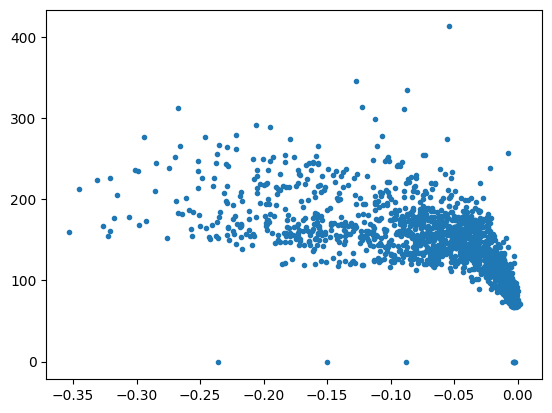

In [ ]:
catalog_id = "39132"
df_one = merged_df[merged_df["catalog"].astype(str) == catalog_id] # single satellite merged df
df_one=df_one.dropna()
plt.plot(df_one['decay_rate'], df_one['mean_f107_adj'], '.') # plot decay rate vs solar flux for a satellite
corr_coeff_f107=np.corrcoef(df_one['decay_rate'], df_one['mean_f107_adj']) # corr_coeff between decay rate and solar flux
corr_coeff_f107

## Correlation coefficients with decay rate: values & a plot

    catalog  corr_coeff_f107  corr_coeff_Ap  corr_coeff_drag  corr_coeff_hp  \
0     39132        -0.703887      -0.304039        -0.906062       0.817297   
1     39418        -0.776985      -0.367009        -0.936741       0.714124   
2     39429        -0.746287      -0.363952        -0.929439       0.610901   
3     40031        -0.589291      -0.324801        -0.840677       0.881026   
4     40072        -0.783869      -0.359374        -0.954388       0.669167   
5     41601         0.058887      -0.006974        -0.018371      -0.007877   
6     41771         0.064919      -0.021356         0.030902      -0.063620   
7     41772        -0.015916      -0.058296        -0.059679      -0.007271   
8     41773         0.038807      -0.010461         0.019237      -0.015072   
9     41774         0.034029      -0.050163         0.019522      -0.029626   
10    42987         0.028096       0.028645         0.072506      -0.040538   
11    42988         0.045480      -0.012296         

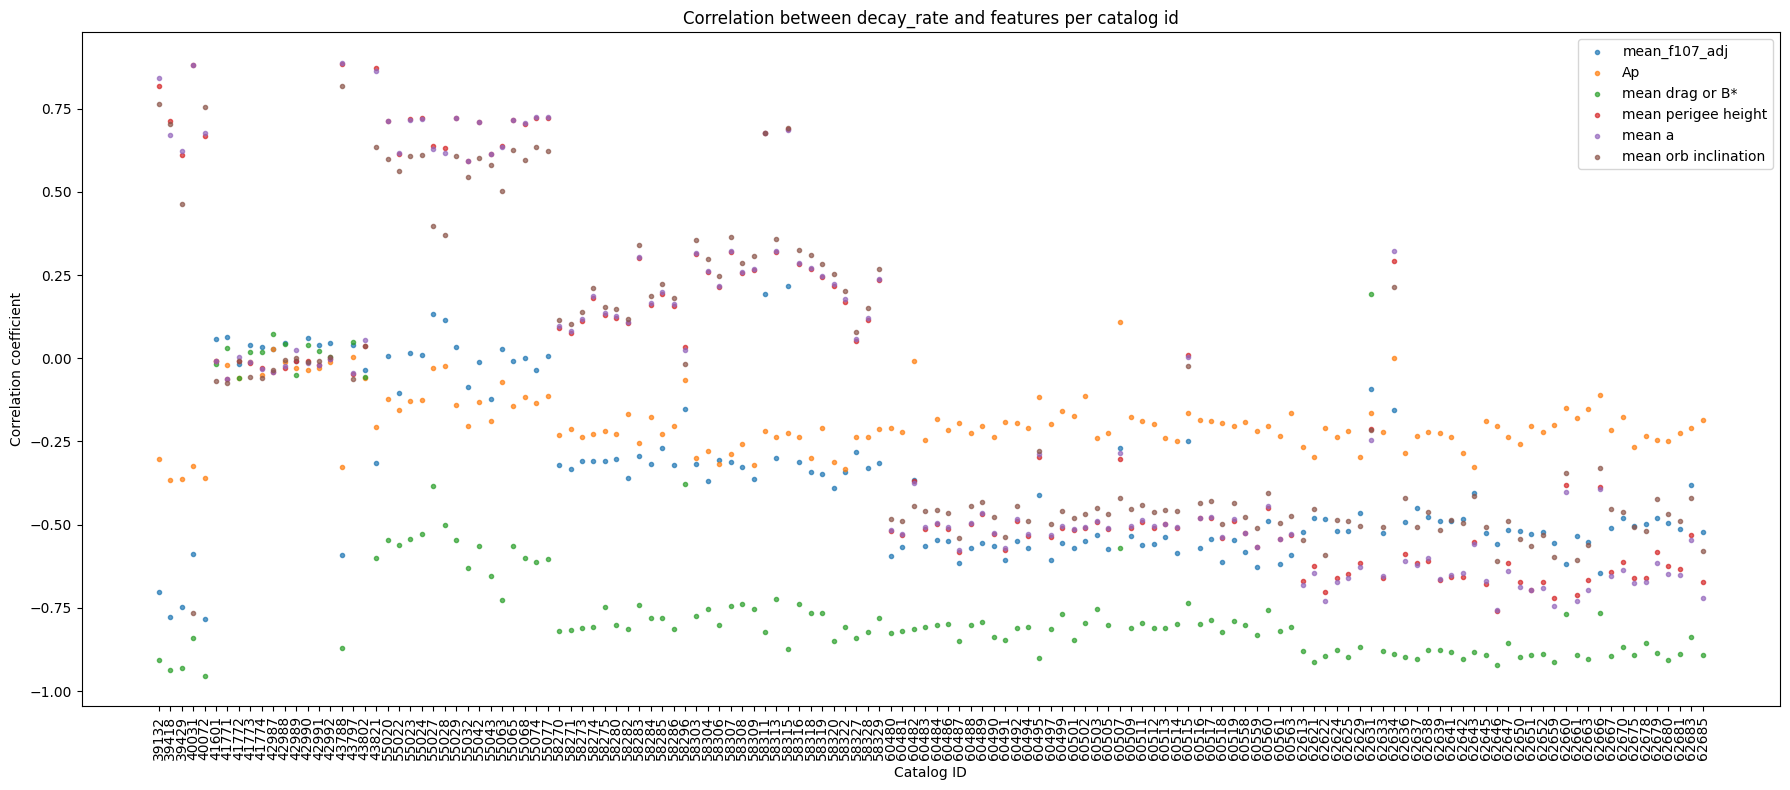

<Figure size 640x480 with 0 Axes>

In [ ]:
merged_df_clean=merged_df.dropna(subset=["decay_rate", "mean_f107_adj","Ap","drag","h_p_km","semi_major_axis_km","orb incli"])
corr_list = []
for catalog_id, group in merged_df_clean.groupby("catalog"):
    if len(group) > 1:  # need at least 2 points for correlation
        corr_1 = np.corrcoef(group["decay_rate"], group["mean_f107_adj"])[0,1]
        corr_2 = np.corrcoef(group["decay_rate"], group["Ap"])[0,1]
        corr_3 = np.corrcoef(group["decay_rate"], group["drag"])[0,1]
        corr_4 = np.corrcoef(group["decay_rate"], group["h_p_km"])[0,1]
        corr_5 = np.corrcoef(group["decay_rate"], group["semi_major_axis_km"])[0,1]
        corr_6 = np.corrcoef(group["decay_rate"], group["orb incli"])[0,1]
        corr_list.append((catalog_id, corr_1, corr_2, corr_3, corr_4,corr_5,corr_6))
#print(corr_list)

corr_df = pd.DataFrame(corr_list, columns=["catalog", "corr_coeff_f107", "corr_coeff_Ap", "corr_coeff_drag","corr_coeff_hp","corr_coeff_a","corr_coeff_incli"])
pd.set_option("display.max_rows", None)     # Show all rows
pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", None)        # Don’t wrap to fit the screen
pd.set_option("display.max_colwidth", None) # Show full column content
print(corr_df)

plt.figure(figsize=(18,8))
plt.scatter(corr_df["catalog"].astype(str), corr_df["corr_coeff_f107"],marker='.', alpha=0.7, label='mean_f107_adj')
plt.scatter(corr_df["catalog"].astype(str), corr_df["corr_coeff_Ap"],marker='.', alpha=0.7, label='Ap')
plt.scatter(corr_df["catalog"].astype(str), corr_df["corr_coeff_drag"],marker='.', alpha=0.7, label='mean drag or B*')
plt.scatter(corr_df["catalog"].astype(str), corr_df["corr_coeff_hp"],marker='.', alpha=0.7, label='mean perigee height')
plt.scatter(corr_df["catalog"].astype(str), corr_df["corr_coeff_a"],marker='.', alpha=0.7, label='mean a')
plt.scatter(corr_df["catalog"].astype(str), corr_df["corr_coeff_incli"],marker='.', alpha=0.7, label='mean orb inclination')
plt.xticks(rotation=90)
plt.xlabel("Catalog ID")
plt.ylabel("Correlation coefficient")
plt.title("Correlation between decay_rate and features per catalog id")
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("corr_coeff_summary.png", dpi=300, bbox_inches='tight')

In [ ]:
# optionally save off the dataframe for use later
geo_solar_df.to_csv("geo_solar.csv")

## XGBoost Regression: cluster modeling for mid altitude and outlier handling


Checking group: (Planet_low, Sun-synchronous) with 1723 rows
After outlier removal: 1686 rows remain
Subgroup 0 with 1686 rows
Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE=0.18359, R²=0.84652, best={'model__colsample_bytree': np.float64(0.9332779646944658), 'model__learning_rate': np.float64(0.02733646535077721), 'model__max_depth': 3, 'model__n_estimators': 761, 'model__reg_lambda': np.float64(7.62522284353982), 'model__subsample': np.float64(0.7246844304357644)}


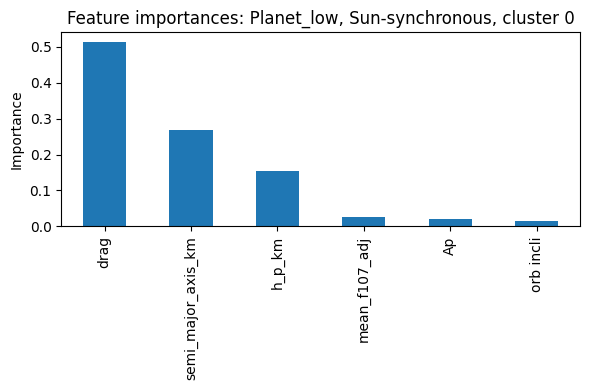


Checking group: (Planet_mid, Polar) with 3291 rows
After outlier removal: 3266 rows remain
Subgroup 0 with 594 rows
Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE=0.03555, R²=0.72212, best={'model__colsample_bytree': np.float64(0.7801997007878172), 'model__learning_rate': np.float64(0.011326496115986653), 'model__max_depth': 3, 'model__n_estimators': 515, 'model__reg_lambda': np.float64(6.632882178455393), 'model__subsample': np.float64(0.7541666010159664)}


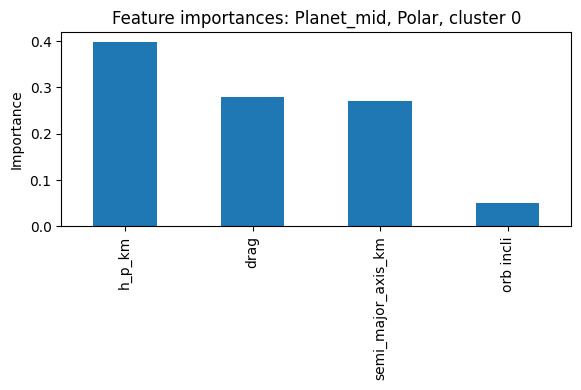

Subgroup 1 with 1313 rows
Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE=0.04661, R²=0.57221, best={'model__colsample_bytree': np.float64(0.662397808134481), 'model__learning_rate': np.float64(0.015808361216819947), 'model__max_depth': 7, 'model__n_estimators': 299, 'model__reg_lambda': np.float64(2.428668179219408), 'model__subsample': np.float64(0.8603553891795411)}


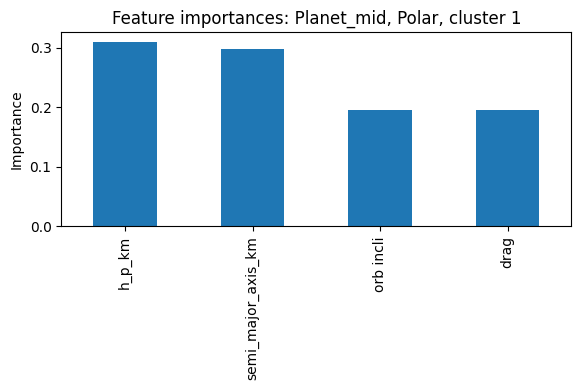

Subgroup 2 with 1359 rows
Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE=0.00664, R²=0.90306, best={'model__colsample_bytree': np.float64(0.9332779646944658), 'model__learning_rate': np.float64(0.02733646535077721), 'model__max_depth': 3, 'model__n_estimators': 761, 'model__reg_lambda': np.float64(7.62522284353982), 'model__subsample': np.float64(0.7246844304357644)}


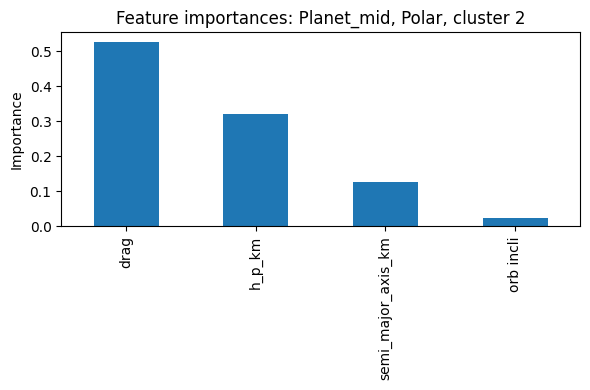


Checking group: (Planet_mid, Sun-synchronous) with 85816 rows
After outlier removal: 83577 rows remain
Subgroup 0 with 30923 rows
Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE=0.03255, R²=0.78668, best={'model__colsample_bytree': np.float64(0.8090931317527976), 'model__learning_rate': np.float64(0.052754101835854966), 'model__max_depth': 4, 'model__n_estimators': 660, 'model__reg_lambda': np.float64(3.017192023353962), 'model__subsample': np.float64(0.9583054382694077)}


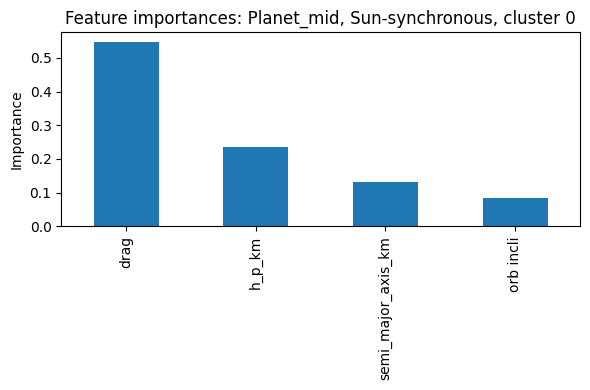

Subgroup 1 with 43301 rows
Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE=0.03060, R²=0.78315, best={'model__colsample_bytree': np.float64(0.9332779646944658), 'model__learning_rate': np.float64(0.02733646535077721), 'model__max_depth': 3, 'model__n_estimators': 761, 'model__reg_lambda': np.float64(7.62522284353982), 'model__subsample': np.float64(0.7246844304357644)}


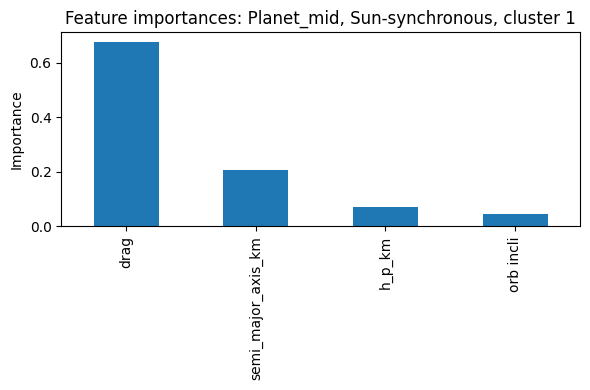

Subgroup 2 with 9353 rows
Fitting 3 folds for each of 30 candidates, totalling 90 fits
RMSE=0.00688, R²=0.92365, best={'model__colsample_bytree': np.float64(0.7801997007878172), 'model__learning_rate': np.float64(0.011326496115986653), 'model__max_depth': 3, 'model__n_estimators': 515, 'model__reg_lambda': np.float64(6.632882178455393), 'model__subsample': np.float64(0.7541666010159664)}


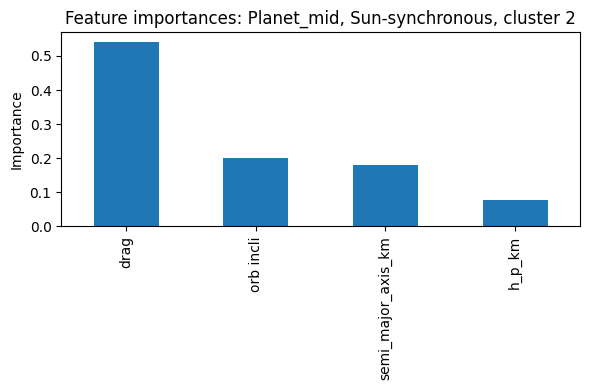

In [ ]:

# required dependencies
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from scipy.stats import uniform, randint

results = {}

# define base features
base_features = ["drag", "h_p_km", "semi_major_axis_km", "orb incli"]

# param distributions for RandomizedSearch (note randint/uniform ranges)
param_distributions = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.1),
    "model__subsample": uniform(0.6, 0.4),          # 0.6–1.0
    "model__colsample_bytree": uniform(0.6, 0.4),   # 0.6–1.0
    "model__reg_lambda": uniform(1, 10)
}

# remove Outliers by IQR
def remove_outliers(df, col, factor=3.0):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return df[(df[col] >= lower) & (df[col] <= upper)]

# ======================
# Main loop
# ======================

all_importances = []   ### initialize list to store FI
for (alt_group, incl_group), group_df in merged_df.groupby(["altitude_group", "incli_group"]):
    print(f"\nChecking group: ({alt_group}, {incl_group}) with {len(group_df)} rows")

    # always start from clean copy
    df = group_df.copy()

    if (alt_group == "Planet_low") and (incl_group == "Sun-synchronous"):
        features = base_features + ["mean_f107_adj", "Ap"]
    else:
        features = base_features

    features = [f for f in features if f in df.columns]  # safety
    df = df.dropna(subset=features + ["decay_rate"])

    if df.empty:
        continue

    # ---- outlier handling ----
    df = remove_outliers(df, "decay_rate", factor=3.0)
    print(f"After outlier removal: {len(df)} rows remain")

    # ---- cluster-based subgrouping for mid-altitude ----
    if alt_group == "Planet_mid":
        # use KMeans on orbital/physical features
        cluster_features = ["drag", "h_p_km", "semi_major_axis_km", "orb incli"]
        cluster_features = [f for f in cluster_features if f in df.columns]

        # normalize for clustering
        X_cluster = df[cluster_features].copy()
        X_cluster = (X_cluster - X_cluster.mean()) / X_cluster.std()

        # choose number of clusters
        kmeans = KMeans(n_clusters=3, random_state=42)
        df["cluster"] = kmeans.fit_predict(X_cluster)
        subgroup_key = "cluster"
    else:
        df["cluster"] = 0  # single subgroup
        subgroup_key = "cluster"

    # ======================
    # Collect feature importances across groups
    # ======================

    # ---- loop subgroups (clusters or single group) ----
    for subgroup, sub_df in df.groupby(subgroup_key):
        print(f"Subgroup {subgroup} with {len(sub_df)} rows")

        if len(sub_df) < 50:
            print("Skipping (too few rows)")
            continue

        X = sub_df[features]
        y = sub_df["decay_rate"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Preprocessing: robust scaling to reduce outlier effect
        numeric_features = X.columns.tolist()
        preprocessor = ColumnTransformer(
            transformers=[("num", RobustScaler(), numeric_features)],
            remainder="passthrough"
        )

        xgb = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)

        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", xgb)
        ])

        # RandomizedSearchCV
        rand_search = RandomizedSearchCV(
            pipe,
            param_distributions,
            n_iter=30,        # try 30 random combos
            cv=3,
            scoring="r2",
            random_state=42,
            n_jobs=-1,
            verbose=1
        )

        rand_search.fit(X_train, y_train)
        best_model = rand_search.best_estimator_

        y_pred = best_model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results[(alt_group, incl_group, subgroup)] = {
            "RMSE": rmse,
            "R2": r2,
            "best_params": rand_search.best_params_
        }

        print(f"RMSE={rmse:.5f}, R²={r2:.5f}, best={rand_search.best_params_}")

        # feature importance plot ---- optional
        fitted_xgb = best_model.named_steps["model"]
        importances = fitted_xgb.feature_importances_
        fi = pd.Series(importances, index=numeric_features).sort_values(ascending=False)
        # store feature importances with group info
        all_importances.append(((alt_group, incl_group, subgroup), fi))


        plt.figure(figsize=(6,4))
        fi.plot(kind="bar")
        plt.title(f"Feature importances: {alt_group}, {incl_group}, cluster {subgroup}")
        plt.ylabel("Importance")
        plt.tight_layout()
        plt.show()


    # ======================
    # Prepare data
    # ======================
    if all_importances:
        # Convert list of (index, Series) → DataFrame
        fi_df = pd.DataFrame({idx: fi for idx, fi in all_importances}).T
        fi_df.index = pd.MultiIndex.from_tuples(fi_df.index, names=["Altitude", "Inclination", "Subgroup"])
        #fi_df = pd.DataFrame(all_importances)
        #fi_df.index = pd.MultiIndex.from_tuples(fi_df.index, names=["Altitude", "Inclination", "Subgroup"])

        # reset index for seaborn plotting
        fi_long = fi_df.reset_index().melt(id_vars=["Altitude", "Inclination", "Subgroup"],
                                          var_name="Feature", value_name="Importance")



## Risk classification: only satellites falling under test set

In [ ]:
from sklearn.metrics import mean_absolute_error

# assume sub_df contains satellite_id column
satellite_results = []

# Predict using best model
y_pred = best_model.predict(X_test)

# collect residuals per sample
residuals_df = pd.DataFrame({
    "satellite_id": sub_df.loc[y_test.index]["catalog"].values,
    "y_true": y_test.values,
    "y_pred": y_pred,
})
residuals_df["residual"] = residuals_df["y_true"] - residuals_df["y_pred"]
residuals_df["abs_residual"] = residuals_df["residual"].abs()

# aggregate per satellite
satellite_mae = (
    residuals_df.groupby("satellite_id")["abs_residual"]
    .mean()
    .reset_index(name="mae_per_satellite")
)

# Risk classification
low_thr = satellite_mae["mae_per_satellite"].quantile(0.33)
high_thr = satellite_mae["mae_per_satellite"].quantile(0.66)

def classify_risk(mae):
    if mae <= low_thr:
        return "Low"
    elif mae <= high_thr:
        return "Medium"
    else:
        return "High"

satellite_mae["risk_category"] = satellite_mae["mae_per_satellite"].apply(classify_risk)



print(satellite_mae.head())


  satellite_id  mae_per_satellite risk_category
0        39418           0.001652           Low
1        39429           0.004461          High
2        40031           0.005563          High
3        40072           0.001437           Low
4        43788           0.002855        Medium


## Risk classification: all satellites

In [ ]:
# use entire merged_df
features_full = base_features.copy()
if "mean_f107_adj" in merged_df.columns and "Ap" in merged_df.columns:
    features_full += ["mean_f107_adj", "Ap"]

# drop NA
df_full = merged_df.dropna(subset=features_full + ["decay_rate", "catalog"])

X_full = df_full[features_full]
y_full = df_full["decay_rate"]

# use best trained model on the full data
y_pred_full = best_model.predict(X_full)

# residuals per satellite entry
residuals_df = pd.DataFrame({
    "satellite_id": df_full["catalog"].values,
    "y_true": y_full.values,
    "y_pred": y_pred_full
})
residuals_df["abs_residual"] = (residuals_df["y_true"] - residuals_df["y_pred"]).abs()

# aggregate per satellite
satellite_mae = residuals_df.groupby("satellite_id")["abs_residual"].mean().reset_index()
satellite_mae.rename(columns={"abs_residual": "mae_per_satellite"}, inplace=True)

# Risk classification - quantile-based thresholds (top 25% = high, bottom 25% = low)
low_thr = satellite_mae["mae_per_satellite"].quantile(0.33)
high_thr = satellite_mae["mae_per_satellite"].quantile(0.66)

def classify_risk(mae):
    if mae <= low_thr:
        return "Low"
    elif mae <= high_thr:
        return "Medium"
    else:
        return "High"

satellite_mae["risk_category"] = satellite_mae["mae_per_satellite"].apply(classify_risk)

print(f"Total satellites classified: {satellite_mae.shape[0]}")
pd.set_option('display.max_rows', 200)
satellite_mae.head()
print(satellite_mae)
satellite_mae.to_csv("all_satellites_risk.csv", index=False)
satellite_mae['risk_category'].value_counts()



Total satellites classified: 136
    satellite_id  mae_per_satellite risk_category
0          39132           0.031051           Low
1          39418           0.004397           Low
2          39429           0.004151           Low
3          40031           0.036230           Low
4          40072           0.001496           Low
5          41601           0.116381          High
6          41771           0.096151          High
7          41772           0.064300          High
8          41773           0.102003          High
9          41774           0.134597          High
10         42987           0.129377          High
11         42988           0.130228          High
12         42989           0.096458          High
13         42990           0.125625          High
14         42991           0.127026          High
15         42992           0.128736          High
16         43788           0.036913           Low
17         43797           0.101083          High
18         43802 

,count
risk_category,
High,46
Low,45
Medium,45


## cluster-wise performance

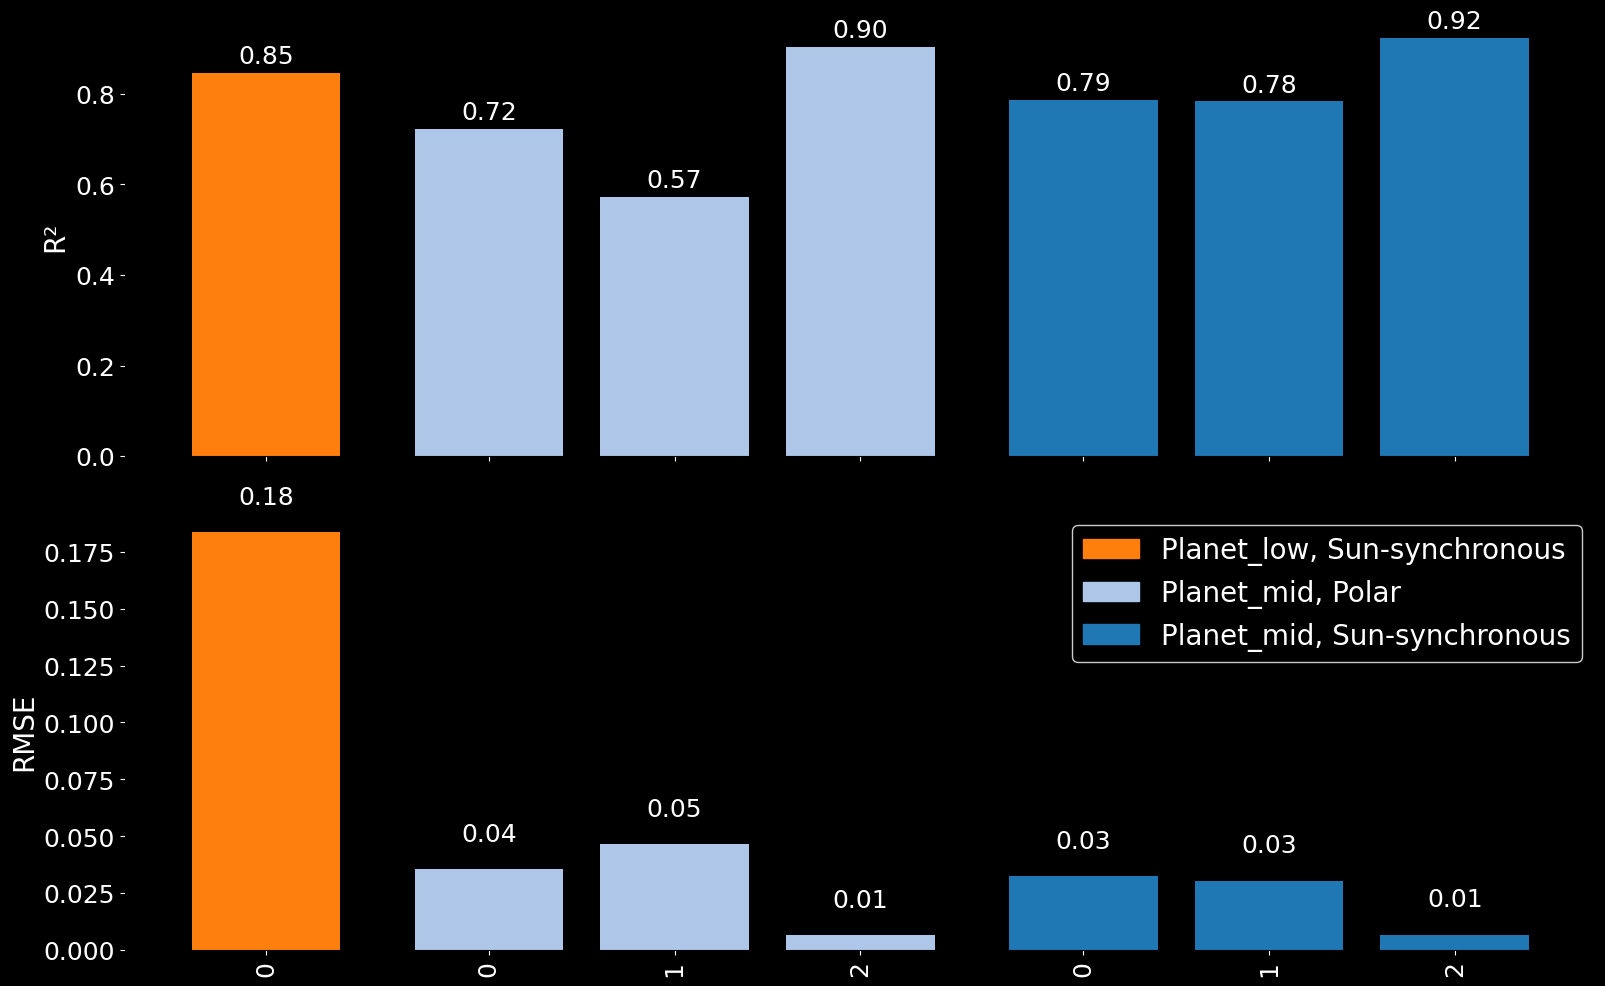

In [ ]:

# convert results dict to DataFrame
summary_df = pd.DataFrame([
    {
        "alt_group": k[0],
        "incl_group": k[1],
        "subgroup": k[2],
        "RMSE": v["RMSE"],
        "R2": v["R2"]
    }
    for k, v in results.items()
])

# sort summary_df by alt_group, incl_group, then subgroup
summary_df = summary_df.sort_values(["alt_group", "incl_group", "subgroup"]).reset_index(drop=True)


base_colors = plt.cm.tab20.colors
color_map = {}
for idx, row in summary_df[["alt_group","incl_group"]].drop_duplicates().iterrows():
    if row['alt_group'] == "Planet_mid":
        if row['incl_group'] == "Polar":
            color_map[tuple(row)] = base_colors[1]  # dark shade
        else:
            color_map[tuple(row)] = base_colors[0]  # light shade
    else:
        color_map[tuple(row)] = base_colors[idx % len(base_colors)]
        color_map[tuple(row)] = base_colors[2]

# define colors for each alt × incl group
alt_incl_groups = summary_df[["alt_group","incl_group"]].drop_duplicates()
#color_map = {tuple(row): plt.cm.tab20(i) for i, row in enumerate(alt_incl_groups.values)}

# X-axis positions with grouping
grouped = summary_df.groupby(["alt_group", "incl_group"])
x = []
x_labels = []
pos = 0
positions = []

for (alt, incl), group in grouped:
    for idx, row in group.iterrows():
        x.append(pos)
        x_labels.append(f"{row['subgroup']}")
        positions.append((pos, row))
        pos += 1
    pos += 0.2  # extra space between groups

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16,10), sharex=True)

# plot R²
for pos, row in positions:
    color = color_map[(row['alt_group'], row['incl_group'])]
    ax1.bar(pos, row["R2"], color=color)
    ax1.text(pos, row["R2"] + 0.01, f"{row['R2']:.2f}", ha='center', va='bottom', fontsize=18)

ax1.set_ylabel("R²", fontsize=20)
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)


#plot RMSE
for pos, row in positions:
    color = color_map[(row['alt_group'], row['incl_group'])]
    ax2.bar(pos, row["RMSE"], color=color)
    ax2.text(pos, row["RMSE"] + 0.01, f"{row['RMSE']:.2f}", ha='center', va='bottom', fontsize=18)

ax2.set_ylabel("RMSE", fontsize=20)
ax2.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='x', labelsize=18)
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=90)

# Legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[tuple(row)]) for idx, row in alt_incl_groups.iterrows()]
labels = [f"{row['alt_group']}, {row['incl_group']}" for idx, row in alt_incl_groups.iterrows()]
#ax1.legend(handles, labels, title="Altitude × Inclination", bbox_to_anchor=(1,1), fontsize=10)
ax2.legend(handles, labels,fontsize=20, loc='upper right', frameon=True)  # legend inside

plt.tight_layout()
plt.savefig("subgroup_R2_RMSE.png", dpi=300)
plt.show()


## mean Feature Importance and bar chart per subgroup

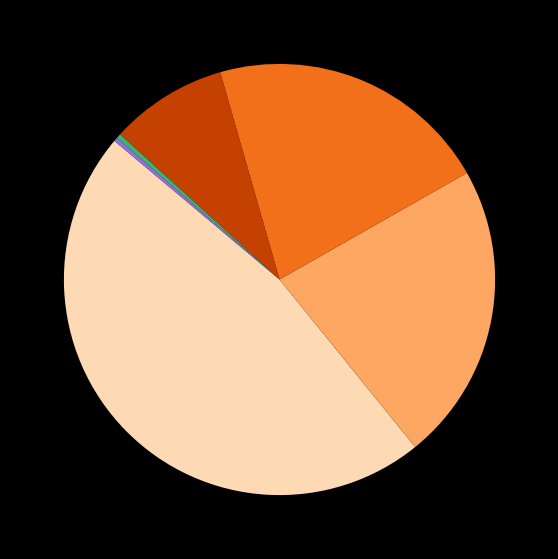

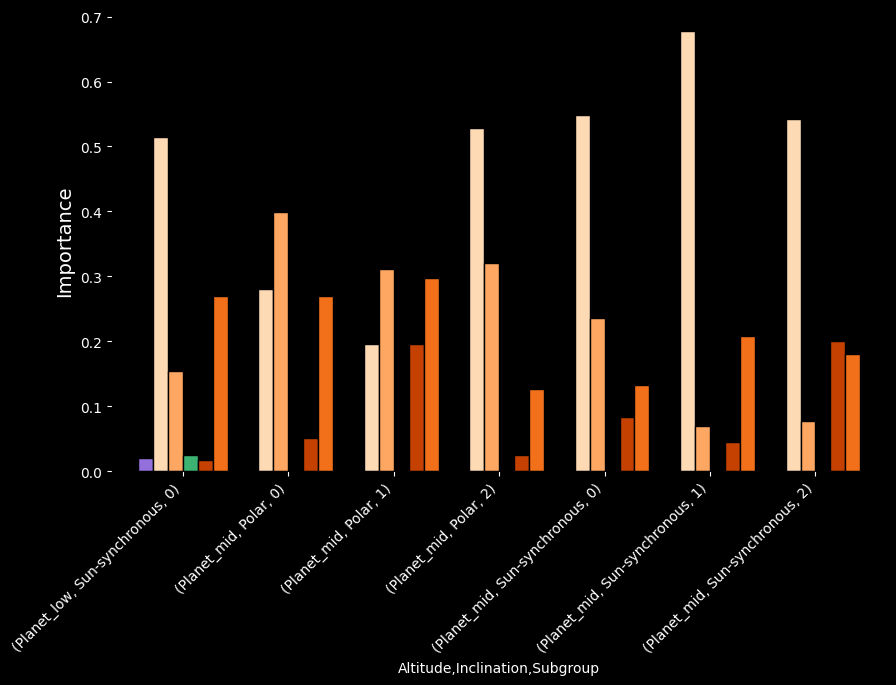

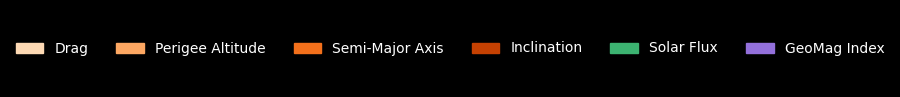

In [ ]:
fi_plot = fi_df.fillna(0)  # fill NaNs with 0 for plotting
# === Assume fi_plot is already defined ===

plt.rcParams['figure.facecolor'] = 'black'    # Figure background
plt.rcParams['axes.facecolor'] = 'black'      # Axes background
plt.rcParams['savefig.facecolor'] = 'black'   # Saved figure background
plt.rcParams['axes.labelcolor'] = 'white'     # Axes labels
plt.rcParams['xtick.color'] = 'white'         # X-axis tick labels
plt.rcParams['ytick.color'] = 'white'         # Y-axis tick labels
plt.rcParams['text.color'] = 'white'          # All text (titles, legends)
plt.rcParams['legend.facecolor'] = 'black'    # Legend background
plt.rcParams['legend.edgecolor'] = 'white'    # Legend border

# rename features for clarity
rename_map = {
    "mean_f107_adj": "Solar Flux",
    "Ap": "GeoMag Index",
    "h_p_km": "Perigee Altitude",
    "semi_major_axis_km": "Semi-Major Axis",
    "orb incli": "Inclination",
    "drag": "Drag"
}
fi_plot_renamed = fi_plot.rename(columns=rename_map)


orbital_features = ["Drag", "Perigee Altitude", "Semi-Major Axis", "Inclination"]
orbital_colors = sns.color_palette("Oranges", n_colors=len(orbital_features))  # new shades
color_map = {feat: col for feat, col in zip(orbital_features, orbital_colors)}
color_map["Solar Flux"] = "mediumseagreen"   # distinct green
color_map["GeoMag Index"] = "mediumpurple"   # distinct purple

# colors list for columns
colors_list = [color_map[col] for col in fi_plot_renamed.columns]

# === Overall Mean Feature Importance Pie Chart ===
mean_fi = fi_plot_renamed.mean().sort_values(ascending=False)

plt.figure(figsize=(7,7))
plt.pie(
    mean_fi.values,
    #labels=mean_fi.index,
    labels=None,
    startangle=140,
    colors=[color_map[feat] for feat in mean_fi.index],
)
#plt.title("Overall Mean Feature Importance", fontsize=14, weight="bold")
plt.savefig("feature_importance_piechart_combined.png", dpi=300, bbox_inches="tight")
plt.show()

# === Grouped Bar Chart per Subgroup ===
plt.figure(figsize=(10,6))
fi_plot_renamed.plot(
    kind="bar",
    ax=plt.gca(),
    width=0.85,
    color=colors_list,
    edgecolor="black",
    legend=False
)
plt.ylabel("Importance", fontsize=14)
#plt.xlabel("Groups (Altitude, Inclination, Subgroup)", fontsize=14)
plt.xticks(rotation=45, ha="right")
#plt.title("Feature Importances by Subgroups", fontsize=14, weight="bold")
#plt.tight_layout()
plt.savefig("feature_importance_bar_combined.png", dpi=300, bbox_inches="tight")
plt.show()



# === Save Common Legend as PNG ===
fig_legend = plt.figure(figsize=(6,1))
handles = [plt.Rectangle((0,0),1,1,color=color_map[feat]) for feat in mean_fi.index]
labels = list(mean_fi.index)
plt.legend(handles, labels, ncol=len(labels), frameon=False, loc="center")
plt.axis("off")
plt.savefig("feature_importance_legend.png", dpi=300, bbox_inches="tight")
#plt.close()
plt.show()




## cluster separation PCA

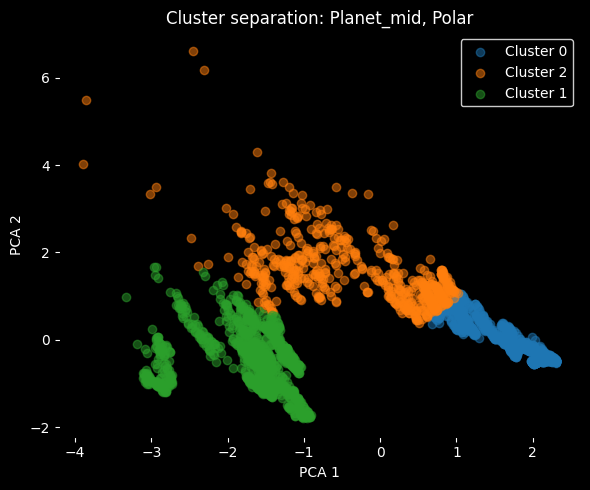

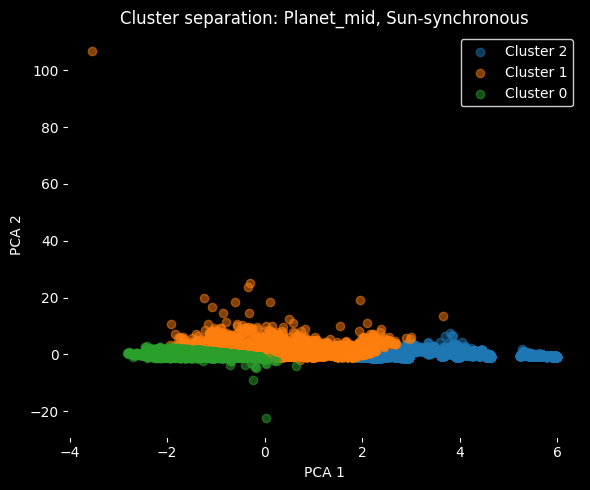

In [ ]:


from sklearn.decomposition import PCA

for (alt_group, incl_group), group_df in merged_df.groupby(["altitude_group", "incli_group"]):
    if alt_group != "Planet_mid":
        continue  # only clustering applied to mid-altitude groups

    df = group_df.copy()
    cluster_features = ["drag", "h_p_km", "semi_major_axis_km", "orb incli"]
    X_cluster = df[cluster_features].copy()
    X_cluster = (X_cluster - X_cluster.mean()) / X_cluster.std()

    kmeans = KMeans(n_clusters=3, random_state=42)
    df["cluster"] = kmeans.fit_predict(X_cluster)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_cluster)

    plt.figure(figsize=(6,5))
    for c in df["cluster"].unique():
        plt.scatter(X_pca[df["cluster"]==c,0], X_pca[df["cluster"]==c,1], alpha=0.5, label=f"Cluster {c}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"Cluster separation: {alt_group}, {incl_group}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Written by Jessica - Download Solar Data as JSON, not used here currently

Kp is calculated from the K values or the geomagnetic recordings 13 geomagnetic observatories, and is also included in geo_solar_df

The derived indices are: ap (linear index) [included in geo_solar_df], Ap (daily mean of ap) [included in geo_solar_df], Cp, C9

In [ ]:
# Grab the JSON for each index and save it off to a json
base_url = "https://kp.gfz.de/app/json/"
time_url = f"?start={start_date}T00%3A00%3A00Z&end={end_date}T23%3A59%3A59Z"
indexes = ["Kp","ap","Ap","Cp","C9"]
for ind in indexes:
    download_url = f"&index={ind}#kpdatadownload-143"
    url = base_url + time_url + download_url
    resp = requests.get(url)
    if resp.status_code == 200:
        f_out = f"{ind}_data.json"
        with open(f_out,'w') as f:
            json.dump(json.loads(resp.text),f)

NameError: name 'start_date' is not defined

In [ ]:
with open("Kp_data.json",'r') as f:
    Kp = json.load(f)
kp_data = pd.DataFrame({"datetime":Kp['datetime'],"Kp":Kp['Kp'],"Kp_status":Kp['status']})
kp_data['datetime'] = pd.to_datetime(kp_data['datetime'],format='ISO8601')
kp_data = kp_data.set_index(kp_data['datetime'])

In [ ]:
with open("ap_data.json",'r') as f:
    ap = json.load(f)
ap_data = pd.DataFrame({"datetime":ap['datetime'],"Ap":ap['Ap'],"Ap_status":ap['Apstatus']})
ap_data['datetime'] = pd.to_datetime(ap_data['datetime'],format='ISO8601')
ap_data = ap_data.set_index(ap_data['datetime'])

In [ ]:
with open("Ap_data.json",'r') as f:
    Ap = json.load(f)
Ap_data = pd.DataFrame({"datetime":Ap['datetime'],"Ap":Ap['Ap']})
Ap_data['datetime'] = pd.to_datetime(Ap_data['datetime'],format='ISO8601')
Ap_data = Ap_data.set_index(ap_data['datetime'])

In [ ]:
with open("Cp_data.json",'r') as f:
    Cp = json.load(f)
Cp_data = pd.DataFrame({"datetime":Cp['datetime'],"Cp":Cp['Cp'],"Cp_status":Cp['status']})
Cp_data['datetime'] = pd.to_datetime(Cp_data['datetime'],format='ISO8601')
Cp_data = Cp_data.set_index(Cp_data['datetime'])

In [ ]:
with open("C9_data.json",'r') as f:
    C9 = json.load(f)
C9_data = pd.DataFrame({"datetime":C9['datetime'],"C9":C9['C9'],"C9_status":C9['status']})
C9_data['datetime'] = pd.to_datetime(C9_data['datetime'],format='ISO8601')
C9_data = C9_data.set_index(C9_data['datetime'])

## EDA

In [ ]:
# plot Mean Motion Derivative a specified NORAD_ID
NORAD_ID = 39132
tle_df[tle_df['satnumber']== str(NORAD_ID)].plot(x='epoch',y='mean_motion_derivative')

In [ ]:
# plot the sunspot number over time
geo_solar_df.plot(x='datetime',y='SN',linestyle='none',marker='.',title="Sunspot #")

In [ ]:
# Plot the KP overtime; note some sources say 6 is a good threshold, so should probably color differently
geo_solar_df.plot(x="datetime",y="kp",linestyle='none',marker='.',title="Kp")